# Intent Classification ML Pipeline
This notebook implements an end-to-end Machine Learning pipeline for conversational Intent Classification.

### Workflow:
1. **Dataset Inspection & Preprocessing**: Ingest CSV training data, verify class distributions, handle whitespace/nulls.
2. **Stratified Split & TF-IDF Extraction**: Create a reproducible 80/20 train/test split and extract sublinear n-gram features.
3. **Model Selection**: Benchmark Logistic Regression, Linear SVM (Calibrated), and Naive Bayes models.
4. **Evaluation & Error Analysis**: Compute Macro F1, Precision, Recall, Accuracy, plot Confusion Matrix, and examine misclassifications.
5. **Persistence & Inference**: Save model pipeline (`.pkl`) and metadata (`.json`), test live predictions with confidence thresholding.

In [1]:
import os
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Set visual styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Inspection & Exploration

In [2]:
# Locate and load the training dataset
csv_paths = [
    'data/chatbot_training_data.csv',
    '../data/chatbot_training_data.csv',
    'ml/data/chatbot_training_data.csv'
]
csv_path = next(p for p in csv_paths if os.path.exists(p))
print(f'Loading dataset from: {os.path.abspath(csv_path)}')

df = pd.read_csv(csv_path)
print(f'Total rows: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'Missing text count: {df["text"].isnull().sum()}')
print(f'Missing intent count: {df["intent"].isnull().sum()}')
print(f'Empty text count: {(df["text"].astype(str).str.strip() == "").sum()}')
print(f'Duplicate text rows: {df["text"].duplicated().sum()}')
print(f'Unique intents: {df["intent"].nunique()}')

df.head(10)

Loading dataset from: C:\Users\nawaz\OneDrive\Desktop\Atlas Chatbot\data\chatbot_training_data.csv
Total rows: 3456
Columns: ['text', 'intent']
Missing text count: 0
Missing intent count: 0
Empty text count: 0
Duplicate text rows: 77
Unique intents: 25


,text,intent
0,Hello,greeting
1,Hey there!,greeting
2,Good morning,greeting
3,"Hi, is anyone there?",greeting
4,"Yo, what's up?",greeting
5,Heyyy,greeting
6,Greetings,greeting
7,hi!,greeting
8,good evening,greeting
9,sup,greeting


C:\Users\nawaz\AppData\Local\Temp\ipykernel_20016\488770912.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=intent_counts.values, y=intent_counts.index, palette='crest')


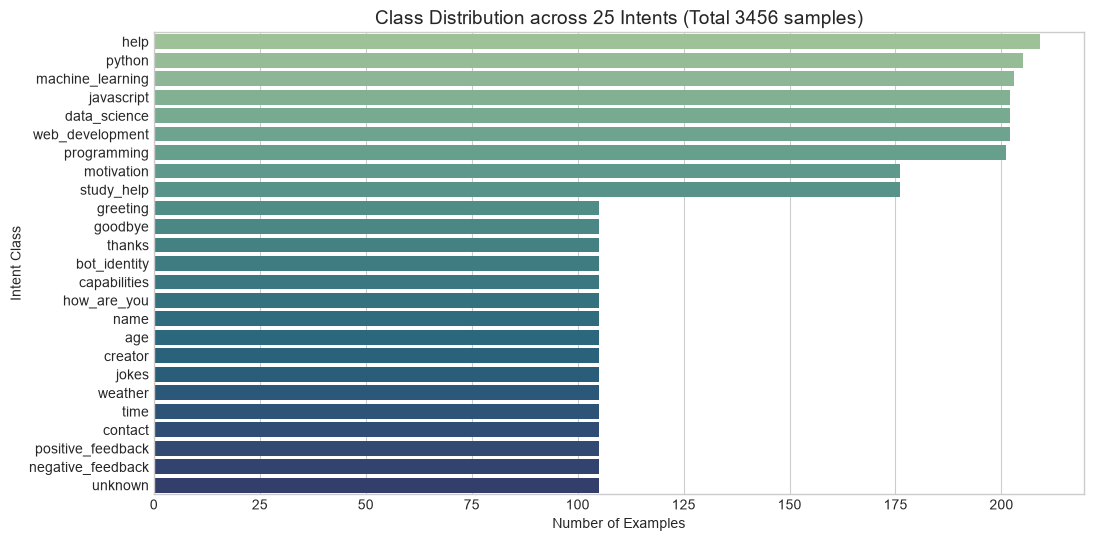

In [3]:
# Class distribution plot
plt.figure(figsize=(12, 6))
intent_counts = df['intent'].value_counts()
sns.barplot(x=intent_counts.values, y=intent_counts.index, palette='crest')
plt.title(f'Class Distribution across {len(intent_counts)} Intents (Total {len(df)} samples)', fontsize=14)
plt.xlabel('Number of Examples')
plt.ylabel('Intent Class')
plt.show()

## 2. Preprocessing & Stratified Train/Test Split

In [4]:
# Preprocess text and perform Stratified Train/Test Split
df_clean = df.dropna(subset=['text', 'intent']).copy()
df_clean['text_clean'] = df_clean['text'].astype(str).str.strip()
df_clean['intent'] = df_clean['intent'].astype(str).str.strip()
df_clean = df_clean[df_clean['text_clean'] != ''].copy()

labels = sorted(df_clean['intent'].unique().tolist())
X = df_clean['text_clean']
y = df_clean['intent']

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, df_clean.index, test_size=0.20, stratify=y, random_state=42
)
raw_texts_test = df_clean.loc[test_idx, 'text'].tolist()

print(f'Training set size: {len(X_train)} samples ({len(X_train)/len(df_clean):.1%})')
print(f'Testing set size:  {len(X_test)} samples ({len(X_test)/len(df_clean):.1%})')
print(f'Unique classes:    {len(labels)}')

Training set size: 2764 samples (80.0%)
Testing set size:  692 samples (20.0%)
Unique classes:    25


## 3. Model Training & Comparison

In [5]:
# Candidate model pipelines with TF-IDF
vectorizer_params = {
    'ngram_range': (1, 2),
    'sublinear_tf': True,
    'strip_accents': 'unicode',
    'min_df': 1,
    'lowercase': True
}

candidate_models = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**vectorizer_params)),
        ('clf', LogisticRegression(C=2.0, max_iter=1000, random_state=42))
    ]),
    'LinearSVC (Calibrated)': Pipeline([
        ('tfidf', TfidfVectorizer(**vectorizer_params)),
        ('clf', CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42), cv=5))
    ]),
    'Multinomial NB': Pipeline([
        ('tfidf', TfidfVectorizer(**vectorizer_params)),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    'Complement NB': Pipeline([
        ('tfidf', TfidfVectorizer(**vectorizer_params)),
        ('clf', ComplementNB(alpha=0.1))
    ])
}

results = {}
reports = {}
conf_matrices = {}

for name, pipeline in candidate_models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {
        'Accuracy': acc,
        'Macro Precision': prec_macro,
        'Macro Recall': rec_macro,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1,
        'Pipeline': pipeline
    }
    reports[name] = classification_report(y_test, y_pred, labels=labels, zero_division=0)
    conf_matrices[name] = confusion_matrix(y_test, y_pred, labels=labels)

# Summary comparison dataframe
comparison_df = pd.DataFrame([
    {
        'Model': k,
        'Accuracy': f'{v["Accuracy"]:.4f}',
        'Macro Precision': f'{v["Macro Precision"]:.4f}',
        'Macro Recall': f'{v["Macro Recall"]:.4f}',
        'Macro F1': f'{v["Macro F1"]:.4f}',
        'Weighted F1': f'{v["Weighted F1"]:.4f}'
    }
    for k, v in results.items()
]).sort_values(by='Macro F1', ascending=False)

print('=== MODEL COMPARISON TABLE ===')
display(comparison_df)

best_model_name = max(results.keys(), key=lambda k: results[k]['Macro F1'])
print(f'\n>>> Selected Best Model: {best_model_name} (Macro F1 = {results[best_model_name]["Macro F1"]:.4f})')

=== MODEL COMPARISON TABLE ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,LinearSVC (Calibrated),0.8772,0.8795,0.8732,0.8719,0.8763
3,Complement NB,0.8613,0.8601,0.8552,0.8510,0.8594
0,Logistic Regression,0.8540,0.8616,0.8468,0.8476,0.8536
2,Multinomial NB,0.7847,0.8394,0.7972,0.8060,0.7905



>>> Selected Best Model: LinearSVC (Calibrated) (Macro F1 = 0.8719)


## 4. In-Depth Evaluation & Error Analysis

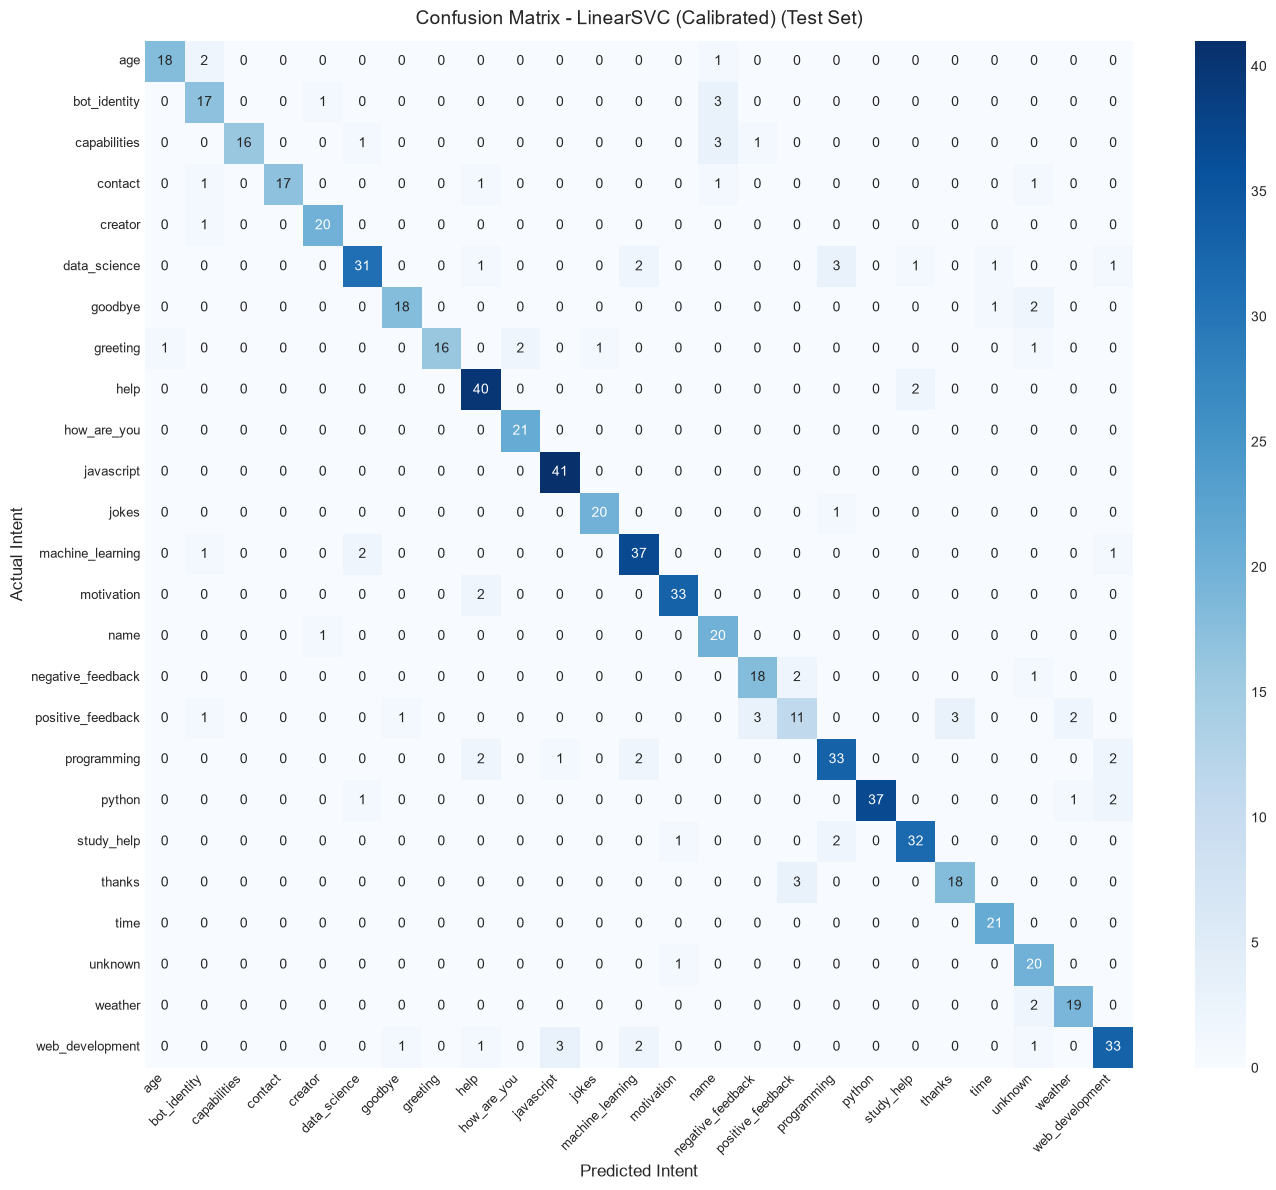

In [6]:
# Confusion Matrix for the Best Model
best_cm = conf_matrices[best_model_name]
plt.figure(figsize=(14, 12))
sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)
plt.title(f'Confusion Matrix - {best_model_name} (Test Set)', fontsize=14, pad=12)
plt.xlabel('Predicted Intent', fontsize=12)
plt.ylabel('Actual Intent', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Inspect misclassifications on the test split
best_pipeline = results[best_model_name]['Pipeline']
y_pred_best = best_pipeline.predict(X_test)
probs_best = best_pipeline.predict_proba(X_test) if hasattr(best_pipeline, 'predict_proba') else None

y_test_arr = np.array(y_test)
misclassified_mask = y_test_arr != y_pred_best

if misclassified_mask.sum() > 0:
    error_df = pd.DataFrame({
        'Input Text': np.array(raw_texts_test)[misclassified_mask],
        'Actual Intent': y_test_arr[misclassified_mask],
        'Predicted Intent': y_pred_best[misclassified_mask],
        'Confidence': [float(np.max(probs_best[i])) if probs_best is not None else 1.0 for i in np.where(misclassified_mask)[0]]
    })
    print(f'Total Misclassifications on Test Set: {len(error_df)} / {len(y_test)}')
    display(error_df)
else:
    print('Zero misclassifications on the test set!')

Total Misclassifications on Test Set: 85 / 692


,Input Text,Actual Intent,Predicted Intent,Confidence
0,really appreciate the clarity of your response,positive_feedback,thanks,0.591663
1,I am very unhappy with this response,negative_feedback,positive_feedback,0.536305
2,define your identity,bot_identity,name,0.753375
3,Can someone help me troubleshoot this website ...,web_development,help,0.558492
4,who r u called,name,creator,0.605357
...,...,...,...,...
80,are you a newly developed bot?,age,bot_identity,0.692454
81,how to scrape web data using beautifulsoup?,python,web_development,0.487095
82,what are word embeddings in NLP?,machine_learning,bot_identity,0.178543
83,what is the global interpreter lock?,python,weather,0.295395


## 5. Model Serialization & Metadata

In [8]:
# Save trained pipeline and metadata
models_dir = 'ml/models' if os.path.exists('ml') else 'models'
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'chatbot_intent_model.pkl')
meta_path = os.path.join(models_dir, 'model_metadata.json')

joblib.dump(best_pipeline, model_path)
print(f'Model pipeline successfully saved to: {model_path}')

best_stats = results[best_model_name]
metadata = {
    'model_name': best_model_name,
    'training_timestamp': datetime.datetime.now(datetime.timezone.utc).isoformat(),
    'total_examples': len(df_clean),
    'num_intents': len(labels),
    'intents': labels,
    'confidence_threshold': 0.50,
    'evaluation_metrics': {
        'accuracy': round(float(best_stats['Accuracy']), 4),
        'precision_macro': round(float(best_stats['Macro Precision']), 4),
        'recall_macro': round(float(best_stats['Macro Recall']), 4),
        'macro_f1': round(float(best_stats['Macro F1']), 4),
        'weighted_f1': round(float(best_stats['Weighted F1']), 4)
    },
    'all_model_benchmarks': {
        k: {
            'accuracy': round(float(v['Accuracy']), 4),
            'macro_f1': round(float(v['Macro F1']), 4),
            'weighted_f1': round(float(v['Weighted F1']), 4)
        } for k, v in results.items()
    }
}

with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata successfully saved to: {meta_path}')

Model pipeline successfully saved to: ml/models\chatbot_intent_model.pkl
Metadata successfully saved to: ml/models\model_metadata.json


## 6. Live Inference & Confidence Thresholding

In [9]:
def predict_intent(text, threshold=0.50):
    '''Predicts intent for arbitrary input text with confidence thresholding.'''
    if not text or not isinstance(text, str) or text.strip() == '':
        return {'intent': 'unknown', 'confidence': 0.0, 'raw_intent': 'unknown'}
    
    cleaned = text.strip()
    if hasattr(best_pipeline, 'predict_proba'):
        probs = best_pipeline.predict_proba([cleaned])[0]
        classes = best_pipeline.classes_
        top_idx = np.argmax(probs)
        top_intent = classes[top_idx]
        confidence = float(probs[top_idx])
    else:
        top_intent = best_pipeline.predict([cleaned])[0]
        confidence = 1.0

    final_intent = top_intent if confidence >= threshold else 'unknown'
    return {
        'intent': final_intent,
        'confidence': round(confidence, 4),
        'raw_intent': top_intent
    }

# Test suite across different intents and unknown queries
sample_queries = [
    'Hey bro',
    'Who are you?',
    'What can you do?',
    'How do I learn Python?',
    'Explain machine learning',
    'How do I build a React website?',
    'Tell me a joke',
    'Thanks for your help',
    'Bye',
    'Quantum superposition in interstellar propulsion'
]

print(f'{"Query":<50} | {"Predicted Intent":<20} | {"Confidence":<10}')
print('-' * 85)
for q in sample_queries:
    res = predict_intent(q, threshold=0.50)
    print(f'{q:<50} | {res["intent"]:<20} | {res["confidence"]:10.4f}')

Query                                              | Predicted Intent     | Confidence
-------------------------------------------------------------------------------------
Hey bro                                            | greeting             |     0.8915
Who are you?                                       | unknown              |     0.4388
What can you do?                                   | capabilities         |     0.8939
How do I learn Python?                             | python               |     0.6573
Explain machine learning                           | machine_learning     |     0.9073
How do I build a React website?                    | web_development      |     0.8291
Tell me a joke                                     | jokes                |     0.9209
Thanks for your help                               | thanks               |     0.9164
Bye                                                | goodbye              |     0.8947
Quantum superposition in interstellar propul